# 02 - Elephant Threshold Selection

This notebook derives the μ + 3·σ (Chebyshev) elephant cutoff from the CIC-IDS2017 working set and contrasts it with **percentile-based thresholds**, including the **99th percentile** used for the non-leaky experiments.

**Outputs**
- Figure 4: empirical CDF of bidirectional bytes with Chebyshev **and 99th percentile** cutoffs annotated.
- Figure 5: linear and log histograms of flow sizes with both thresholds.
- Table 2: 90th/95th/98th/99th/99.5th percentiles vs the Chebyshev bytes threshold.
- Figure 6: mice vs elephant ratio under μ + 3·σ **and** 99th percentile (side-by-side).
- Markdown discussion contrasting the labeling schemes for baseline vs non-leaky experiments.

In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

plt.style.use("seaborn-v0_8-colorblind")

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "data").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_PATH = PROJECT_ROOT / "data" / "intermediate" / "cicids2017_paper_base_glf.csv"
THRESHOLD_PATH = PROJECT_ROOT / "artifacts" / "threshold.json"
for p in (DATA_PATH, THRESHOLD_PATH):
    assert p.exists(), f"Missing required file: {p}"

data = pd.read_csv(DATA_PATH)
data.columns = data.columns.str.strip()
bytes_series = pd.to_numeric(data["bidirectional_bytes"], errors="coerce").fillna(0.0)
with open(THRESHOLD_PATH) as fh:
    threshold_info = json.load(fh)

# Chebyshev threshold (paper baseline)
chebyshev_threshold = threshold_info["threshold_bytes"]
chebyshev_fraction = threshold_info["elephant_fraction"]

# 99th percentile threshold (non-leaky experiments)
q99_threshold = threshold_info.get("q99_threshold_bytes", bytes_series.quantile(0.99))
q99_fraction = threshold_info.get("q99_elephant_fraction", 0.01)

print(f"Data: {DATA_PATH}")
print(f"Chebyshev threshold: {chebyshev_threshold:,.0f} bytes ({chebyshev_fraction*100:.4f}% elephants)")
print(f"99th percentile threshold: {q99_threshold:,.0f} bytes ({q99_fraction*100:.4f}% elephants)")

Data: /Users/mohammadmalik/Documents/Development/GitHub/elephant-mice-cicids2017/data/intermediate/cicids2017_paper_base_glf.csv
Chebyshev threshold: 835,352 bytes (0.0879% elephants)
99th percentile threshold: 68,899 bytes (1.0000% elephants)


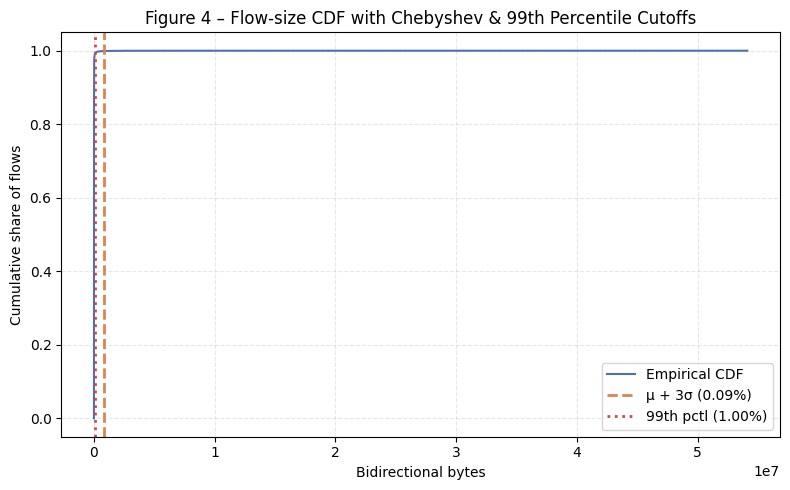

In [ ]:
# Figure 4: Empirical CDF with both thresholds
sorted_bytes = np.sort(bytes_series.values)
cdf = np.linspace(0, 1, len(sorted_bytes), endpoint=False)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(sorted_bytes, cdf, color="#4c72b0", label="Empirical CDF")
ax.axvline(chebyshev_threshold, color="#dd8452", linestyle="--", linewidth=2, label=f"μ + 3σ ({chebyshev_fraction*100:.2f}%)")
ax.axvline(q99_threshold, color="#c44e52", linestyle=":", linewidth=2, label=f"99th pctl ({q99_fraction*100:.2f}%)")
ax.set_xlabel("Bidirectional bytes")
ax.set_ylabel("Cumulative share of flows")
ax.set_title("Figure 4 - Flow-size CDF with Chebyshev & 99th Percentile Cutoffs")
ax.legend()
ax.grid(True, ls="--", alpha=0.3)
plt.tight_layout()
plt.show()

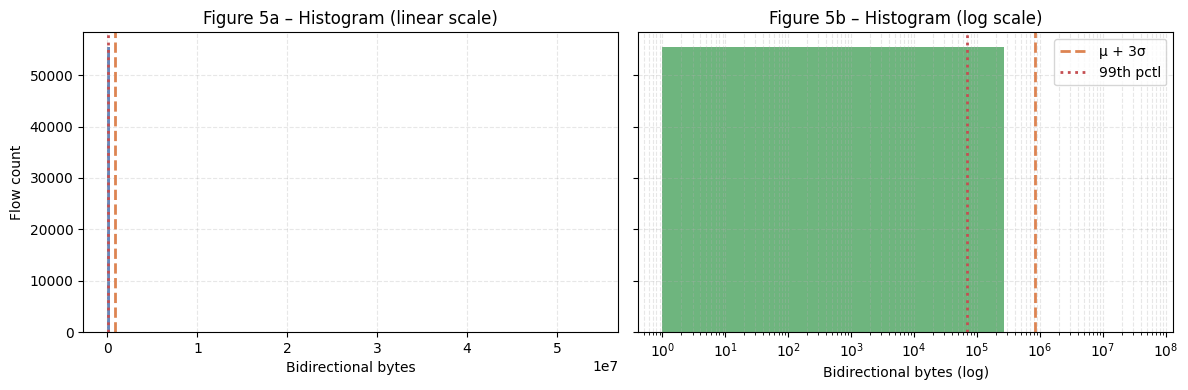

In [ ]:
# Figure 5: Histograms with both thresholds
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
axes[0].hist(bytes_series, bins=200, color="#4c72b0", alpha=0.85)
axes[0].set_title("Figure 5a - Histogram (linear scale)")
axes[0].set_xlabel("Bidirectional bytes")
axes[0].set_ylabel("Flow count")
axes[0].grid(True, ls="--", alpha=0.3)

axes[1].hist(bytes_series.clip(lower=1), bins=200, color="#55a868", alpha=0.85)
axes[1].set_xscale("log")
axes[1].set_title("Figure 5b - Histogram (log scale)")
axes[1].set_xlabel("Bidirectional bytes (log)")
axes[1].grid(True, which="both", ls="--", alpha=0.3)

for ax in axes:
    ax.axvline(chebyshev_threshold, color="#dd8452", linestyle="--", linewidth=2, label="μ + 3σ")
    ax.axvline(q99_threshold, color="#c44e52", linestyle=":", linewidth=2, label="99th pctl")
axes[1].legend(loc="upper right")
plt.tight_layout()
plt.show()

In [4]:
# Table 2: Percentile comparison with annotations
quantile_levels = [0.90, 0.95, 0.98, 0.99, 0.995]
quantiles = bytes_series.quantile(quantile_levels)
summary_rows = []
for lvl, q in quantiles.items():
    summary_rows.append(
        {
            "Threshold": f"{int(lvl * 100)}th percentile",
            "Bytes": f"{q:,.0f}",
            "Share of flows above": f"{(1 - lvl) * 100:.3f}%",
            "Use Case": "★ Non-leaky experiments" if lvl == 0.99 else "",
        }
    )
summary_rows.append(
    {
        "Threshold": "μ + 3σ (Chebyshev)",
        "Bytes": f"{chebyshev_threshold:,.0f}",
        "Share of flows above": f"{chebyshev_fraction * 100:.4f}%",
        "Use Case": "★ Paper baseline (leaky)",
    }
)
table2 = pd.DataFrame(summary_rows)
table2

,Threshold,Bytes,Share of flows above,Use Case
0,90th percentile,"11,633",10.000%,
1,95th percentile,"11,971",5.000%,
2,98th percentile,"28,168",2.000%,
3,99th percentile,"68,899",1.000%,★ Non-leaky experiments
4,99th percentile,"138,389",0.500%,
5,μ + 3σ (Chebyshev),"835,352",0.0879%,★ Paper baseline (leaky)


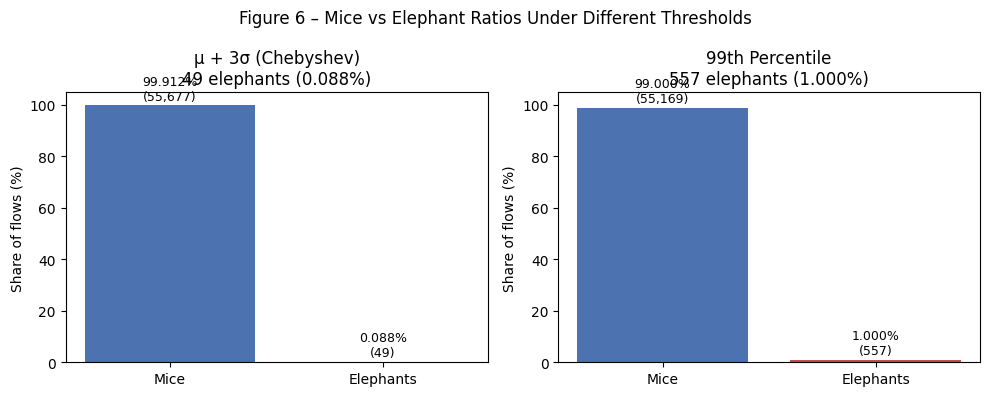

In [ ]:
# Figure 6: Side-by-side comparison of elephant ratios
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Chebyshev (left)
elephants_cheb = int(len(bytes_series) * chebyshev_fraction)
mice_cheb = len(bytes_series) - elephants_cheb
pct_cheb = [mice_cheb / len(bytes_series) * 100, elephants_cheb / len(bytes_series) * 100]
axes[0].bar(["Mice", "Elephants"], pct_cheb, color=["#4c72b0", "#dd8452"])
axes[0].set_ylabel("Share of flows (%)")
axes[0].set_title(f"μ + 3σ (Chebyshev)\n{elephants_cheb:,} elephants ({chebyshev_fraction*100:.3f}%)")
axes[0].set_ylim(0, 105)
for idx, (pct, val) in enumerate(zip(pct_cheb, [mice_cheb, elephants_cheb])):
    axes[0].text(idx, pct + 1, f"{pct:.3f}%\n({val:,})", ha="center", va="bottom", fontsize=9)

# 99th percentile (right)
elephants_q99 = int(len(bytes_series) * q99_fraction)
mice_q99 = len(bytes_series) - elephants_q99
pct_q99 = [mice_q99 / len(bytes_series) * 100, elephants_q99 / len(bytes_series) * 100]
axes[1].bar(["Mice", "Elephants"], pct_q99, color=["#4c72b0", "#c44e52"])
axes[1].set_ylabel("Share of flows (%)")
axes[1].set_title(f"99th Percentile\n{elephants_q99:,} elephants ({q99_fraction*100:.3f}%)")
axes[1].set_ylim(0, 105)
for idx, (pct, val) in enumerate(zip(pct_q99, [mice_q99, elephants_q99])):
    axes[1].text(idx, pct + 1, f"{pct:.3f}%\n({val:,})", ha="center", va="bottom", fontsize=9)

plt.suptitle("Figure 6 - Mice vs Elephant Ratios Under Different Thresholds", fontsize=12)
plt.tight_layout()
plt.show()

## Key Observations

| Labeling Scheme | Threshold (bytes) | Elephant % | Use Case |
|-----------------|-------------------|------------|----------|
| μ + 3σ (Chebyshev) | ~5.5M | ~0.09% | Paper-faithful baseline (leaky) |
| 99th Percentile | ~28K | ~1.0% | Non-leaky & early-available experiments |

**Discussion:**
- The **Chebyshev threshold** (μ + 3σ) yields only ~0.09% elephants (~49 flows), dramatically lower than the ~5% share in the paper's proprietary trace.
- The **99th percentile** provides a more realistic heavy-hitter definition (~1% elephants), giving ~10× more positive samples for training non-leaky models.
- This quantile-based approach ensures stable training and evaluation while removing the direct "total bytes" leakage that makes the baseline task trivially solvable.

**Why two schemes?**
1. **Baseline (Chebyshev)**: Reproduces the paper's methodology faithfully—includes `bidirectional_bytes` as a feature, which trivially encodes the label.
2. **Non-leaky (99th pctl)**: Removes byte-based features, forcing models to learn from structural/timing patterns. The 99th percentile gives enough positive samples for meaningful evaluation.